[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/angeld222/CasalsFranco/blob/main/entornos_complejos/notebook_1_monte_carlo.ipynb)



# **Estudio 1: Monte Carlo On-Policy en Blackjack**

**Autores:** Gloria Casals y Ángel Franco



In [ ]:
# Clonamos el repositorio
!git clone https://github.com/AngelD222/CasalsFranco.git

Cloning into 'CasalsFranco'...
remote: Enumerating objects: 508, done.
remote: Counting objects: 100% (243/243), done.
remote: Compressing objects: 100% (212/212), done.
remote: Total 508 (delta 50), reused 1 (delta 1), pack-reused 265 (from 1)
Receiving objects: 100% (508/508), 125.51 KiB | 4.18 MiB/s, done.
Resolving deltas: 100% (147/147), done.


In [ ]:
# Instalación de dependencias
!pip install gymnasium tqdm matplotlib

import os
import sys
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

repo_name = 'CasalsFranco/entornos_complejos'

# Añadimos la ruta al sistema
if f'/content/{repo_name}' not in sys.path:
    sys.path.append(f'/content/{repo_name}')

print("Archivos en el directorio:")
!ls /content/{repo_name}

from src.utils.seeder import set_seed, make_env
from src.utils.trainer import train_agent
from src.agents.monte_carlo import AgentMonteCarloTodasVisitas
from src.utils.plotter import plot_episode_rewards, plot_episode_lengths, plot_win_rate

# Fijamos las semillas para garantizar la reproducibilidad
SEMILLA = 2026
set_seed(SEMILLA)

Archivos en el directorio:
README.md  src
Usando dispositivo: cpu


## **1. Introducción al Problema y Entorno**

El entorno seleccionado para este primer estudio es **Blackjack-v1** de Gymnasium. Es un entorno episódico clásico que encaja con la naturaleza de las técnicas de Monte Carlo, las cuales esperan a que el agente llegue al estado terminal para considerar el episodio y actualizar su política.

El espacio de estados es una tupla discreta que incluye: la suma actual del jugador, la carta mostrada por el crupier y si el jugador tiene un As usable. Las acciones son discretas: pedir carta (1) o plantarse (0).

Para este estudio planteamos **dos experimentos independientes**.




## **2. Diseño del Agente**

El agente `AgentMonteCarloTodasVisitas` ha sido diseñado bajo la **Iteración de la Política Generalizada (GPI)**.

* **Política del Agente ($\epsilon$-greedy con decaimiento):** Para garantizar una exploración adecuada en un entorno estocástico, la política selecciona una acción aleatoria con probabilidad $\epsilon$ y la acción voraz (la que maximiza el valor Q) con probabilidad $1 - \epsilon$. El valor de $\epsilon$ decae a lo largo del entrenamiento.
* **Actualización del Valor (Evaluación):** Al carecer de un modelo de transiciones, el agente aprende de la experiencia calculando el retorno acumulado $G_t$ hacia atrás al final de cada episodio:
    
    $$G_t = R_{t+1} + \gamma G_{t+1}$$

    El valor $Q(S_t, A_t)$ se actualiza de forma incremental utilizando el método de "Todas las Visitas":
    
    $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \frac{1}{N(S_t, A_t)} [G_t - Q(S_t, A_t)]$$
    
    *Nota:* En el juego de Blackjack la probabilidad de visitar el mismo estado dos veces en un solo episodio es nula. Por lo tanto este algoritmo se comporta de manera idéntica a Monte Carlo de Primera Visita en este entorno específico.

## **3. Diseño Experimental**



In [ ]:
# Configuración del experimento
EPISODIOS = 500000
hiperparametros = {'gamma': 1.0, 'epsilon': 1.0} # Si ponemos gamma<1.0 estaríamos penalizando las trayectorias más largas en el episodio

### **3.1. EXPERIMENTO 1: Impacto de la Tasa de Exploración**

Para no limitarnos a crear un experimento estándar, planteamos la siguiente hipótesis: **¿Cómo afecta la velocidad de decaimiento de la exploración ($\epsilon$) a la convergencia y estabilidad de la política en EL Blackjack?**

Entrenaremos dos agentes con la misma semilla pero diferentes tasas de decaimiento:
1.  **Agente A (Exploración Rápida):** Decaimiento rápido (`decay_rate = 0.0001`), el agente confía en su conocimiento adquirido pronto.
2.  **Agente B (Exploración Lenta):** Decaimiento lento (`decay_rate = 0.00001`), el agente explora el espacio de estados durante mucho más tiempo.

Entrenaremos cada agente durante 500,000 episodios para mmitigar la varianza alta del algoritmo de Monte Carlo y el propio juego de casino.

In [ ]:

# 1. Agente Rápido
env_rapido = make_env("Blackjack-v1", seed=SEMILLA)
agent_rapido = AgentMonteCarloTodasVisitas(env_rapido, hiperparametros)
print("Entrenando Agente (Decaimiento Rápido)...")
stats_rapido = train_agent(env_rapido, agent_rapido, EPISODIOS, initial_eps=1.0, final_eps=0.01, decay_rate=0.0001)

# 2. Agente Lento
env_lento = make_env("Blackjack-v1", seed=SEMILLA)
agent_lento = AgentMonteCarloTodasVisitas(env_lento, hiperparametros)
print("\nEntrenando Agente (Decaimiento Lento)...")
stats_lento = train_agent(env_lento, agent_lento, EPISODIOS, initial_eps=1.0, final_eps=0.01, decay_rate=0.00001)

Entrenando Agente (Decaimiento Rápido)...


Entrenando agente: 100%|██████████| 500000/500000 [01:38<00:00, 5078.36it/s]



Entrenando Agente (Decaimiento Lento)...


Entrenando agente: 100%|██████████| 500000/500000 [01:26<00:00, 5776.85it/s]


### **3.2. EXPERIMENTO 2: Aversión al riesgo**

En el juego estándar, perder contra el crupier o pasarse de 21 ("bust") penaliza igual ($-1$). Alteraremos el Proceso de Decisión de Markov (MDP) usando un `Wrapper` de Gymnasium para castigar el "bust" con un $-5.0$. De esta forma el agente debería desarrollar una política conservadora, lo cual se reflejará en una caída de la métrica $f(t) = len(episodio_t)$ al evitar la acción de pedir cartas.

In [ ]:
class PenalizeBustWrapper(gym.Wrapper):
    """Wrapper que penaliza severamente pasarse de 21"""
    def __init__(self, env, bust_penalty=-5.0):
        super().__init__(env)
        self.bust_penalty = bust_penalty

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # En Blackjack, la observación 0 es la suma del jugador
        if terminated and obs[0] > 21:
            reward = self.bust_penalty
        return obs, reward, terminated, truncated, info

# 3. Agente Averso al Riesgo
env_base = make_env("Blackjack-v1", seed=SEMILLA)
env_penalizado = PenalizeBustWrapper(env_base, bust_penalty=-5.0)
agent_averso = AgentMonteCarloTodasVisitas(env_penalizado, hiperparametros)
print("\nEntrenando Agente Averso al Riesgo (Penalización -5.0)...")
stats_averso = train_agent(env_penalizado, agent_averso, EPISODIOS, initial_eps=1.0, final_eps=0.01, decay_rate=0.0001)


Entrenando Agente Averso al Riesgo (Penalización -5.0)...


Entrenando agente: 100%|██████████| 500000/500000 [01:23<00:00, 5953.64it/s]


## **4. Análisis de Resultados**

Para evaluar el aprendizaje, debido a la alta varianza de los retornos en Monte Carlo y la estocasticidad de Blackjack, consideramos apropiado aplicar medias móviles (ventana = 10,000 episodios) para observar la convergencia real.

AGENTE RÁPIDO (Exploración Rápida)


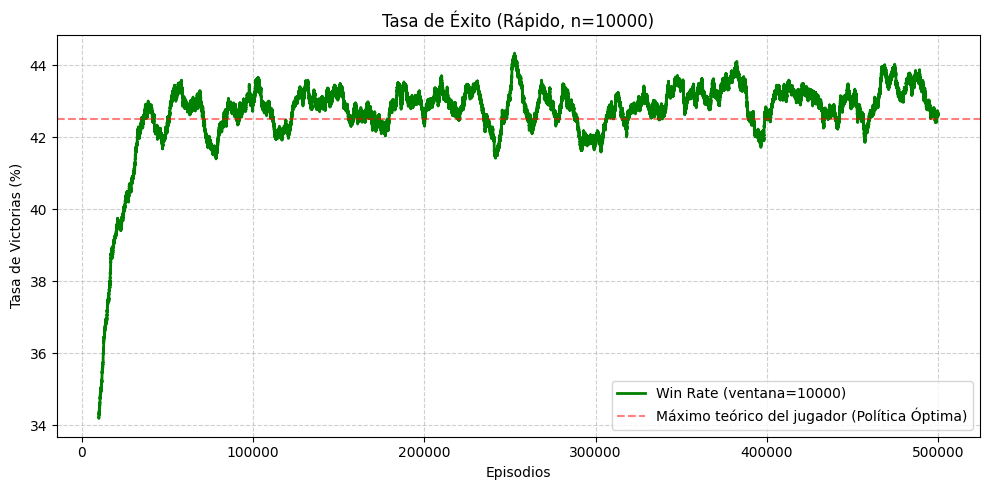

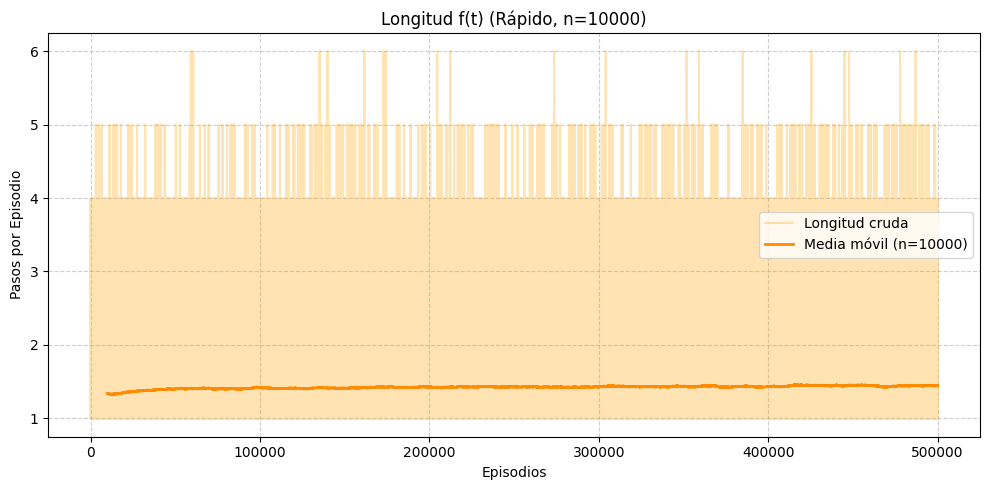

AGENTE LENTO (Exploración Profunda)


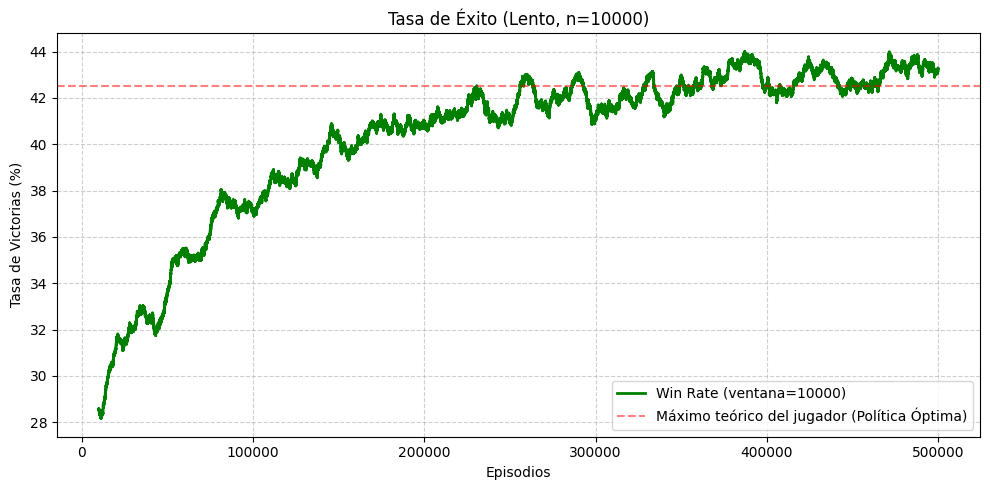

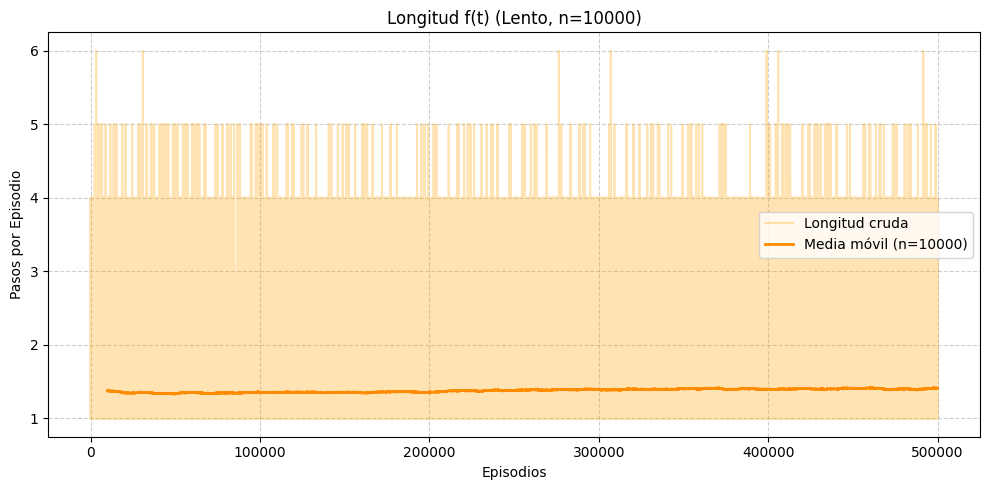

AGENTE AVERSO AL RIESGO (Penalización -5)


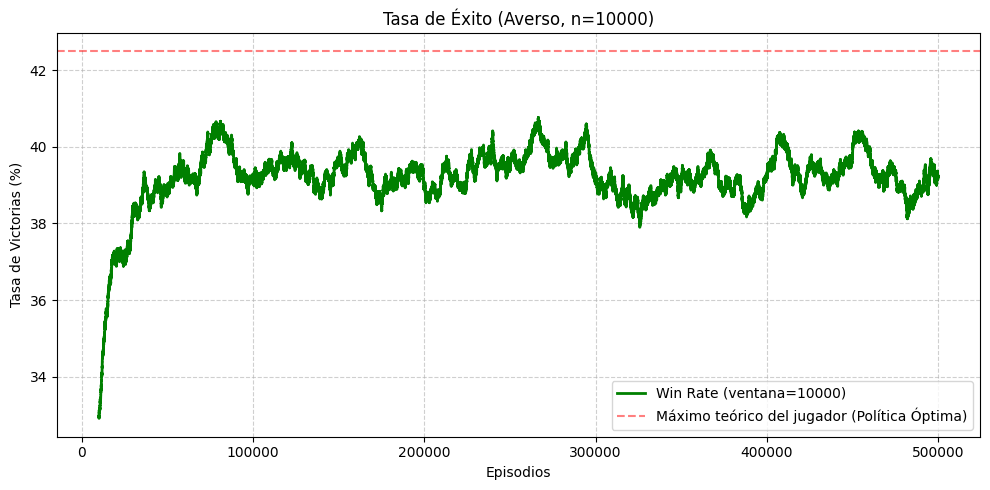

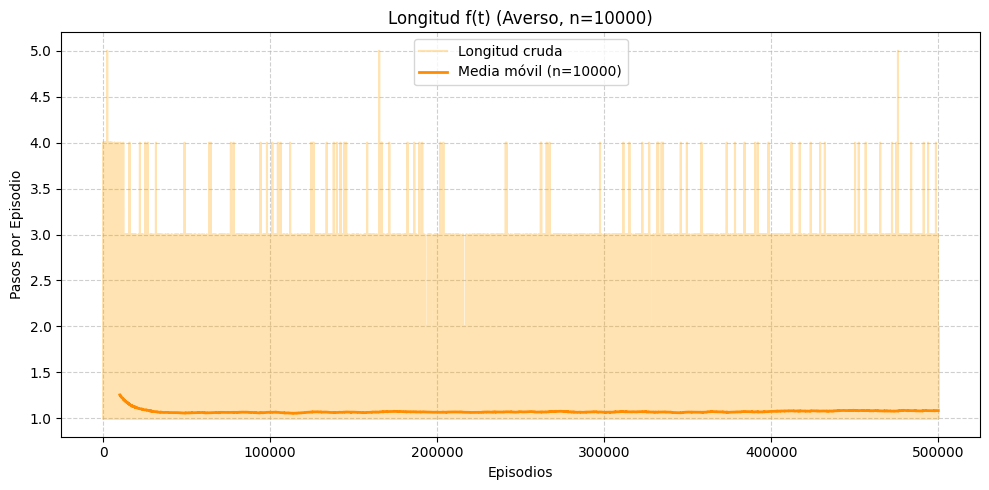

In [ ]:
VENTANA = 10000

print("AGENTE RÁPIDO (Exploración Rápida)")
plot_win_rate(stats_rapido, window_size=VENTANA, title=f"Tasa de Éxito (Rápido, n={VENTANA})")
plot_episode_lengths(stats_rapido, window_size=VENTANA, title=f"Longitud f(t) (Rápido, n={VENTANA})")

print("AGENTE LENTO (Exploración Profunda)")
plot_win_rate(stats_lento, window_size=VENTANA, title=f"Tasa de Éxito (Lento, n={VENTANA})")
plot_episode_lengths(stats_lento, window_size=VENTANA, title=f"Longitud f(t) (Lento, n={VENTANA})")

print("AGENTE AVERSO AL RIESGO (Penalización -5)")
plot_win_rate(stats_averso, window_size=VENTANA, title=f"Tasa de Éxito (Averso, n={VENTANA})")
plot_episode_lengths(stats_averso, window_size=VENTANA, title=f"Longitud f(t) (Averso, n={VENTANA})")

**1. Sobre la tasa de exploración (Experimento 1):**

- *Agente Decaimiento Rápido:* Alcanza la convergencia asintótica hacia la política óptima teórica (~42.5% de victorias) de forma muy temprana, estabilizándose en torno a los 50.000 episodios. Al reducir la exploración rápidamente, el agente explota el conocimiento adquirido y maximiza su rendimiento casi desde el inicio del entrenamiento.

- *Agente Decaimiento Lento:* Tiene una fase de aprendizaje subóptima más prolongada. Debido a la alta tasa de exploración forzada tarda aproximadamente 250.000 - 300.000 episodios en cruzar el umbral del máximo teórico.

En ambos escenarios, la longitud media del episodio converge rápidamente y se estabiliza en torno a 1.3 - 1.4 pasos por episodio. Por tanto la métrica $f(t)$ es invariante frente a la tasa de decaimiento en este entorno. Las decisiones exploratorias no alargan ni acortan significativamente la vida del episodio.

Por tanto en el entorno de Blackjack una tasa de decaimiento rápida es superior. Una exploración prolongada no descubre estrategias superiores, simplemente introduce ruido estocástico durante los episodios, penalizando el rendimiento sin aportar una mejora final en la política óptima.

**2. Sobre la aversión al riesgo (Experimento 2):**

La tasa de victorias del agente con aversión al riesgo se estabiliza en el rango del 38% - 40%, manteniéndose por debajo del máximo teórico del juego. Esto es totalmente coherente con lo que esperábamos, ya que el agente ya no está optimizado para ganar el mayor número de partidas, sino para maximizar el retorno acumulado $G_t$. Al evitar la penalización de $-5.0$ prefiere plantarse con manos débiles antes que arriesgarse a pedir carta y sufrir la penalización de $-5$.

En la gráfica de longitud del episodio también vemos que la media móvil cae en torno a 1.1 pasos por episodio (frente a los ~1.3 - 1.4 pasos de los agentes del experimento anterior). La acción dominante en casi todo los episodios pasa a ser "plantarse" en el primer turno.

La métrica $f(t)$ demuestra ser un indicador sensible y válido para medir la aversión al riesgo en entornos de toma de decisiones como este.

# **Estudio 2: Monte Carlo Off-Policy en Blackjack**

En este segundo estudio abordamos el problema de la exploración desde una perspectiva diferente utilizando **Monte Carlo Off-Policy**.

En los métodos On-Policy el agente aprende sobre la misma política que usa para tomar decisiones. Esto implica que la política final siempre retiene un grado de exploración, lo que la hace subóptima. En **Off-Policy**, separamos el aprendizaje en dos políticas.




### **1. Diseño del Agente Off-Policy**

El agente `AgentMonteCarloOffPolicy` aprende la política óptima mientras sigue un comportamiento exploratorio. Para lograrlo separamos el aprendizaje en dos políticas:

* **Política de Comportamiento ($b$):** Es la encargada de generar los episodios. En nuestro caso, mantendremos una política $\epsilon$-greedy con un valor $\epsilon=0.3$ constante (sin decaimiento) para asegurar que el agente nunca deje de explorar el entorno.
* **Política Objetivo ($\pi$):** Es la política que estamos evaluando y mejorando. Es determinista y voraz respecto a la matriz $Q(s,a)$ actual: $\pi(s) = \arg\max_a Q(s,a)$.

Como estamos generando episodios con $b$ pero queremos evaluar $\pi$, los retornos $G_t$ que obtenemos están sesgados. Para corregir esto *Sutton y Barto* introducen el Muestreo de Importancia.



## **2. Ejecución y visualización**

In [ ]:

from src.agents.monte_carlo_off import AgentMonteCarloOffPolicy

EPISODIOS = 500000

# Configuración del experimento Off-Policy
# Mantenemos una exploración constante del 30% para la política de comportamiento
hiperparametros_off = {'gamma': 1.0, 'epsilon': 0.3}
env_off = make_env("Blackjack-v1", seed=SEMILLA)
agent_off = AgentMonteCarloOffPolicy(env_off, hiperparametros_off)

print("\nEntrenando Agente Off-Policy:")
# Usamos decay_rate = 0.0 para que el epsilon se mantenga constante en 0.3
stats_off = train_agent(env_off, agent_off, EPISODIOS, initial_eps=0.3, final_eps=0.3, decay_rate=0.0)


Entrenando Agente Off-Policy:


Entrenando agente: 100%|██████████| 500000/500000 [01:20<00:00, 6194.04it/s]


AGENTE OFF-POLICY (Exploración Constante = 0.3)


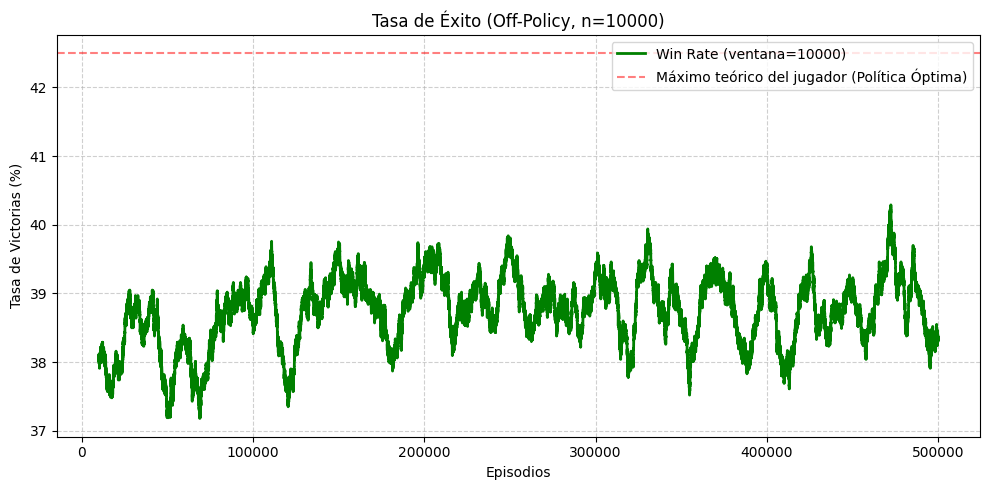

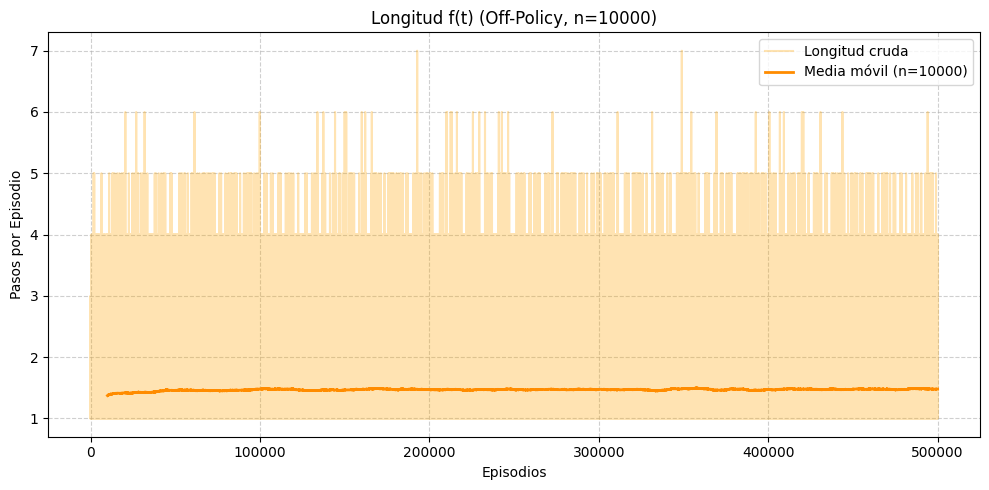

In [ ]:
# métricas del agente Off-Policy
VENTANA = 10000

print("AGENTE OFF-POLICY (Exploración Constante = 0.3)")
plot_win_rate(stats_off, window_size=VENTANA, title=f"Tasa de Éxito (Off-Policy, n={VENTANA})")
plot_episode_lengths(stats_off, window_size=VENTANA, title=f"Longitud f(t) (Off-Policy, n={VENTANA})")


# **Estudio 3: Evaluación voraz post-Entrenamiento**

Debemos tener en cuenta que en el aprendizaje por Refuerzo el rendimiento durante la fase de entrenamiento no refleja necesariamente la calidad de la política que se está aprendiendo, especialmente cuando existe una exploración forzada.

Para aislar y medir el conocimiento real adquirido por ambos agentes, planteamos un último experimento  que separa por un lado el **comportamiento** y por otro, el **aprendizaje**:

- Fase de entrenamiento: Imponemos una política de comportamiento con un $\epsilon = 0.5$ constante (50% de decisiones aleatorias, sin decaimiento) durante 500.000 episodios.

- Fase de evaluación (explotación pura): Una vez alcanzada la convergencia en las tablas $Q(s,a)$, quitaremos por completo la exploración ajustando $\epsilon = 0$. Ejecutaremos una evaluación estrictamente voraz (greedy) para comprobar la eficacia real de la política óptima ($\pi^*$) que cada agente ha logrado aprender a partir de esos datos.

In [ ]:
# Evaluación con epsilon = 0.5
EPISODIOS_CAOS = 500000
hiper_caos = {'gamma': 1.0, 'epsilon': 0.5}

print("1. Entrenando On-Policy")
env_on_caos = make_env("Blackjack-v1", seed=SEMILLA)
agent_on_caos = AgentMonteCarloTodasVisitas(env_on_caos, hiper_caos)
train_agent(env_on_caos, agent_on_caos, EPISODIOS_CAOS, initial_eps=0.5, final_eps=0.5, decay_rate=0.0)

print("2. Entrenando Off-Policy")
env_off_caos = make_env("Blackjack-v1", seed=SEMILLA)
agent_off_caos = AgentMonteCarloOffPolicy(env_off_caos, hiper_caos)
train_agent(env_off_caos, agent_off_caos, EPISODIOS_CAOS, initial_eps=0.5, final_eps=0.5, decay_rate=0.0)

# Evaluación con epsilon = 0.0
EPISODIOS_EVAL = 500000

def evaluar_agente_voraz(agente, env, num_episodios):
    """Evalúa la tabla Q aprendida sin exploración"""
    agente.epsilon = 0.0 # Apagamos la exploración
    victorias = 0
    for _ in range(num_episodios):
        obs, _ = env.reset()
        done = False
        while not done:
            action = np.argmax(agente.q_table[obs]) # Acción estrictamente voraz
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        if reward == 1.0:
            victorias += 1
    return (victorias / num_episodios) * 100

print("\n--- RESULTADOS DE LA EVALUACIÓN VORAZ ---")
win_rate_on = evaluar_agente_voraz(agent_on_caos, env_on_caos, EPISODIOS_EVAL)
win_rate_off = evaluar_agente_voraz(agent_off_caos, env_off_caos, EPISODIOS_EVAL)

print(f"Win Rate de On-Policy aprendido bajo caos: {win_rate_on:.2f}%")
print(f"Win Rate de Off-Policy aprendido bajo caos: {win_rate_off:.2f}%")

1. Entrenando On-Policy


Entrenando agente: 100%|██████████| 500000/500000 [01:22<00:00, 6041.61it/s]


2. Entrenando Off-Policy


Entrenando agente: 100%|██████████| 500000/500000 [01:19<00:00, 6263.22it/s]



--- RESULTADOS DE LA EVALUACIÓN VORAZ ---
Win Rate de On-Policy aprendido bajo caos: 43.15%
Win Rate de Off-Policy aprendido bajo caos: 43.22%


# **Conclusiones On-Policy vs. Off-Policy**

El agente On-Policy con decaimiento rápido ha demostrado ser la estrategia más eficiente para este entorno de Blackjack, alcanzando la convergencia hacia la política óptima teórica en 50.000 episodios.

Al analizar las gráficas del agente Off-Policy con $\epsilon=0.3$ en su fase de entrenamiento podemos observar principalmente:

1. La tasa de victorias oscila entre el 37% y el 40%, sin llegar a tocar el techo teórico del 42.5%. Esto ocurre porque el agente está forzado a tomar decisiones aleatorias el 30% de las veces durante los 500.000 episodios, lo que reduce su rendimiento.

2. Alta varianza: La curva de victorias es más errática. Al multiplicar los ratios de probabilidad entre la política objetivo ($\pi$) y la de comportamiento ($b$), la varianza de las actualizaciones de la tabla $Q(s,a)$ sube, dificultando una convergencia suave.

También podemos concluir que la el experimento de aversión al riesgo muestra que el algoritmo es optimizador del retorno $G_t$. Al penalizar el bust con un $-5.0$, el agente reduce la longitud del episodio ($f(t) \approx 1.05$) y obtiene una tasa de victorias menor (~39%). Esto demuestra que la política óptima es siempre dependiente de la definición de la recompensa, y no depende de las reglas del juego.

**Aprendizaje vs comportamiento**

A pesar de las limitaciones visuales del algoritmo Off-Policy durante el entrenamiento, el experimento final de evaluación voraz nos enseña su verdadero rendimiento. Al apagar la exploración vemos que el agente Off-Policy había aprendido perfectamente, alcanzando un Win Rate del 43.22% (el máximo teórico).


Con esto nos damos cuenta de que las gráficas de entrenamiento pueden ser engañosas si no se aísla la política aprendida. Mientras que el algoritmo On-Policy es más estable cuando su exploración decae gradualmente, el algoritmo Off-Policy es capaz de aprender la política óptima pura a partir de un historial de datos ruidosos y subóptimos.

Cabe mencionar que como el espacio de estados de Blackjack es pequeño (unos 280-320 estados posibles), al entrenar un agente durante 500.000 episodios, todas las semillas convergerán prácticamente a la misma tabla Q y a la misma tasa de éxito.